# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [1]:
%pip install tensorflow
import pandas as pd
df_tic_tac= pd.read_csv('tic-tac-toe.csv')


Note: you may need to restart the kernel to use updated packages.


In [2]:
print(df_tic_tac.head())


  TL TM TR ML MM MR BL BM BR  class
0  x  x  x  x  o  o  x  o  o   True
1  x  x  x  x  o  o  o  x  o   True
2  x  x  x  x  o  o  o  o  x   True
3  x  x  x  x  o  o  o  b  b   True
4  x  x  x  x  o  o  b  o  b   True


In [3]:
# Map target class to 1 and 0
df_tic_tac['class'] = df_tic_tac['class'].map({True: 1, False: 0})

# Make a list of features to encode (all board squares)
feature_cols =  ['TL', 'TM', 'TR', 'ML', 'MM', 'MR', 'BL', 'BM', 'BR']

# Encode feature columns
df_encoded = pd.get_dummies(df_tic_tac, columns=feature_cols)

In [4]:
print(df_encoded.columns)

Index(['class', 'TL_b', 'TL_o', 'TL_x', 'TM_b', 'TM_o', 'TM_x', 'TR_b', 'TR_o',
       'TR_x', 'ML_b', 'ML_o', 'ML_x', 'MM_b', 'MM_o', 'MM_x', 'MR_b', 'MR_o',
       'MR_x', 'BL_b', 'BL_o', 'BL_x', 'BM_b', 'BM_o', 'BM_x', 'BR_b', 'BR_o',
       'BR_x'],
      dtype='object')


In [5]:
#define target 'y'
y = df_encoded['class']

# define feastures x
X = df_encoded.drop(columns='class')

## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11,stratify=y)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(units=16, activation='relu', input_shape= (27,)))

model.add(Dense(units=8, activation='relu'))

model.add(Dense(units=2, activation='softmax'))

c:\Users\PC GAMING\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy')

In [9]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6216 - val_loss: 0.6177
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5954 - val_loss: 0.6049
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5780 - val_loss: 0.5944
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5651 - val_loss: 0.5847
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5524 - val_loss: 0.5774
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5427 - val_loss: 0.5684
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5321 - val_loss: 0.5581
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5219 - val_loss: 0.5480
Epoch 9/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5112 - val_loss: 0.5399
Epoch 10/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5012 - val_loss: 0.5296
Epoch 11/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4884 - val_loss: 0.5175
Epoch 12/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4761 - val_lo

In [10]:

model.evaluate(X_test, y_test)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1587 


0.15870900452136993

In [11]:
model.save('tic-tac-toe.keras')


## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [12]:
from tensorflow.keras.models import load_model

# Load the saved model back into memory under a new variable name
loaded_model = load_model('tic-tac-toe.keras')


In [13]:
# Sample 5 random rows from our test features
X_sample = X_test.sample(5)

# Get the corresponding true answers for those same 5 games
y_sample = y_test.loc[X_sample.index]


In [14]:
import numpy as np

# Make predictions on the sample features
raw_predictions = loaded_model.predict(X_sample)

# Convert probabilities to predicted classes (0 or 1)
predicted_classes = np.argmax(raw_predictions, axis=1)

# Compare them side-by-side!
for true_val, pred_val in zip(y_sample, predicted_classes):
    print(f"Actual Class: {true_val} | Predicted Class: {pred_val} | Correct? {true_val == pred_val}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Actual Class: 1 | Predicted Class: 1 | Correct? True
Actual Class: 1 | Predicted Class: 1 | Correct? True
Actual Class: 1 | Predicted Class: 1 | Correct? True
Actual Class: 1 | Predicted Class: 1 | Correct? True
Actual Class: 0 | Predicted Class: 0 | Correct? True


## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

In [15]:
# 1. Import the Adam optimizer class
from tensorflow.keras.optimizers import Adam

# 2. Instantiate it with a custom learning rate (e.g., 0.005 or 0.01)
custom_optimizer = Adam(learning_rate=0.005)

# 3. Pass it to the compile step
model.compile(
    optimizer=custom_optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)


In [ ]:

import pandas as pd
history_df = pd.DataFrame(history.history)


print(history_df.tail())



        loss  val_loss
25  0.194802  0.223039
26  0.177684  0.203803
27  0.163195  0.187798
28  0.151422  0.177367
29  0.142942  0.158709


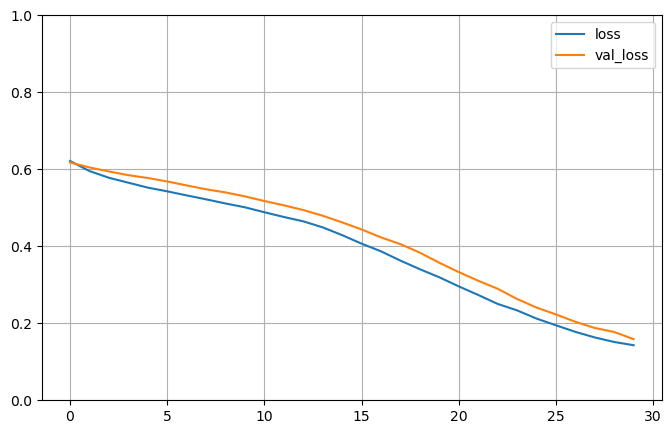

In [ ]:
import matplotlib.pyplot as plt

history_df.plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) 
plt.show()



**Which approach(es) did you find helpful to improve your model performance?**

In [16]:
# your answer here